In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import jax
import jax.numpy as jnp
import numpy as np
from liesel_ptm.model import OnionPTMLocScale
from liesel_ptm.nodes import VarInverseGamma, LinearTerm
from liesel_ptm import history_to_df
import plotnine as p9
import pandas as pd

In [24]:
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)

beta = jnp.array([0.0, 1.0, -0.5])
X = jax.random.uniform(k1, shape=(1000, 3), minval=-2.0, maxval=2.0)
y = X @ beta + jax.random.normal(k2, shape=(X.shape[0],))

Xd = jnp.c_[jnp.ones(X.shape[0]), X]
beta_hat = jnp.linalg.inv(Xd.T @ Xd) @ Xd.T @ y

In [25]:
model = OnionPTMLocScale(
    y=y, 
    nparam=15, 
    tau2=VarInverseGamma(0.01, concentration=2.0, scale=0.5, name="tau2"),
)

model.loc_model += LinearTerm(x=X, name="lin")

In [26]:
res1 = model.optimize_locscale(atol=0.001, max_iter=1000, patience=300)

liesel_ptm.model - INFO - Optimizing location and scale parameters.
liesel_ptm.model - INFO - Building model graph. No changes to the model can be made after this step.
liesel.model.model - INFO - Converted dtype of Data(name="lin_coef_value").value
Training loss: 1511.255, Validation loss: 1511.255:  45%|████▌     | 454/999 [00:08<00:03, 158.73it/s]liesel_ptm.model - INFO - Optimizing location and scale parameters finished after 454 iterations.


In [27]:
res2 = model.optimize_transformation(atol=0.001, max_iter=1000, patience=300)

liesel_ptm.model - INFO - Optimizing transformation parameters.
Training loss: 1509.217, Validation loss: 1509.218:  43%|████▎     | 434/999 [00:09<00:03, 155.12it/s]liesel_ptm.model - INFO - Optimizing transformation parameters finished after 434 iterations.


In [28]:
hist1 = history_to_df(res1.history)
hist1.head()

,loss_train,loss_validation,lin_coef0,lin_coef1,lin_coef2,iteration
0,1958.503174,1958.503174,0.000000,0.000000,0.000000,0
1,1951.211792,1951.211914,0.010000,0.010000,-0.010000,1
2,1943.962646,1943.962646,0.019846,0.020001,-0.019998,2
3,1936.757690,1936.757812,0.029341,0.030004,-0.029993,3
4,1929.595581,1929.595703,0.038175,0.040009,-0.039984,4


<Axes: xlabel='iteration'>

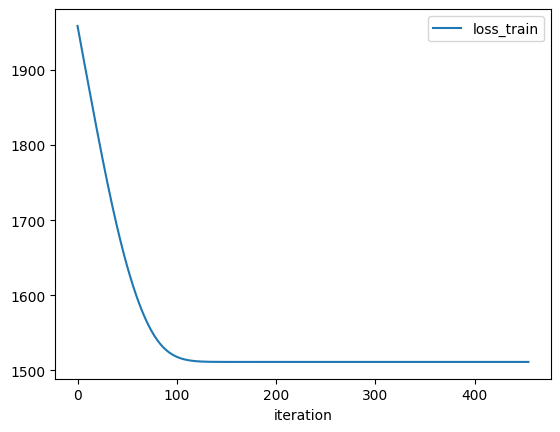

In [29]:
hist1[["loss_train", "iteration"]].plot("iteration")

<Axes: xlabel='iteration'>

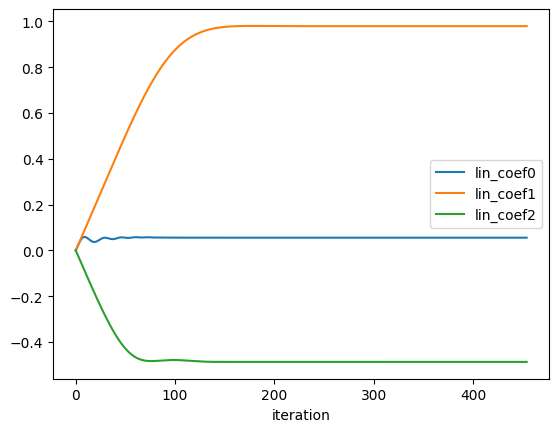

In [30]:
history_to_df(res1.history["position"]).plot("iteration")

<Axes: xlabel='iteration'>

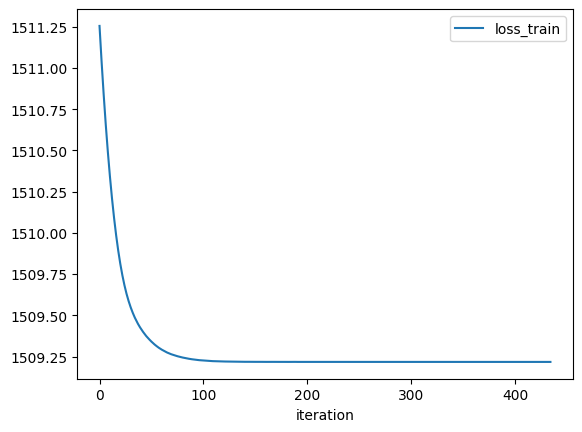

In [31]:
history_to_df(res2.history)[["loss_train", "iteration"]].plot("iteration")

<Axes: xlabel='iteration'>

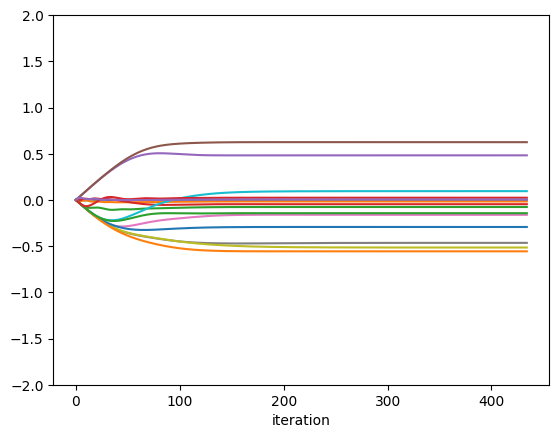

In [33]:
history_to_df(res2.history["position"]).plot("iteration", legend=False, ylim=(-2, 2))

<Axes: xlabel='iteration'>

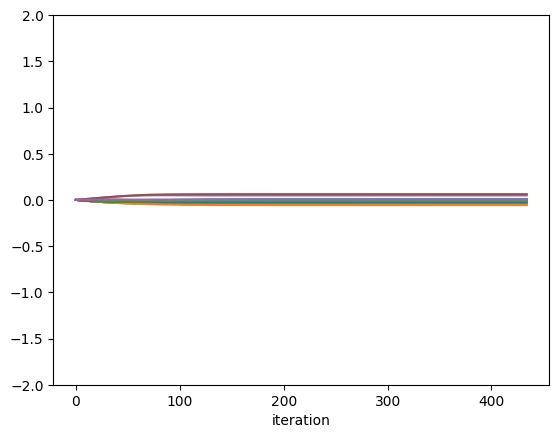

Training loss: 1509.217, Validation loss: 1509.218:  43%|████▎     | 434/999 [00:27<00:03, 155.12it/s]

In [32]:
pos = res2.history["position"] | {model.tau2.transformed.name: model.tau2.transformed.value}

coef_hist2 = model.coef.log_increments.predict(pos)
history_to_df({"coef": coef_hist2}).plot("iteration", legend=False, ylim=(-2, 2))

<Axes: xlabel='iteration'>

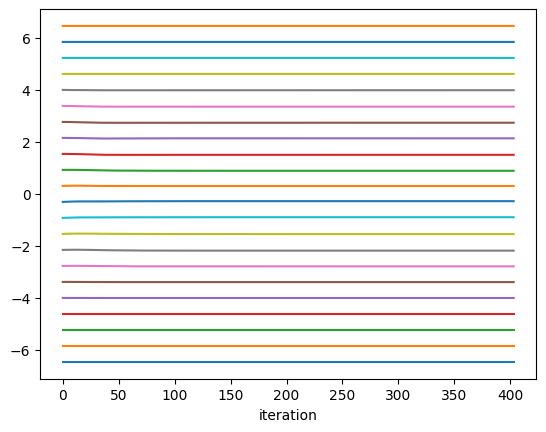

In [12]:
coef_hist2 = model.coef.predict(pos)
history_to_df({"coef": coef_hist2}).plot("iteration", legend=False)

In [14]:
dist = model.init_dist()
residual, _ = dist.transformation_and_logdet_parametric(model.response.value)
z, _ = dist.transformation_and_logdet(model.response.value)

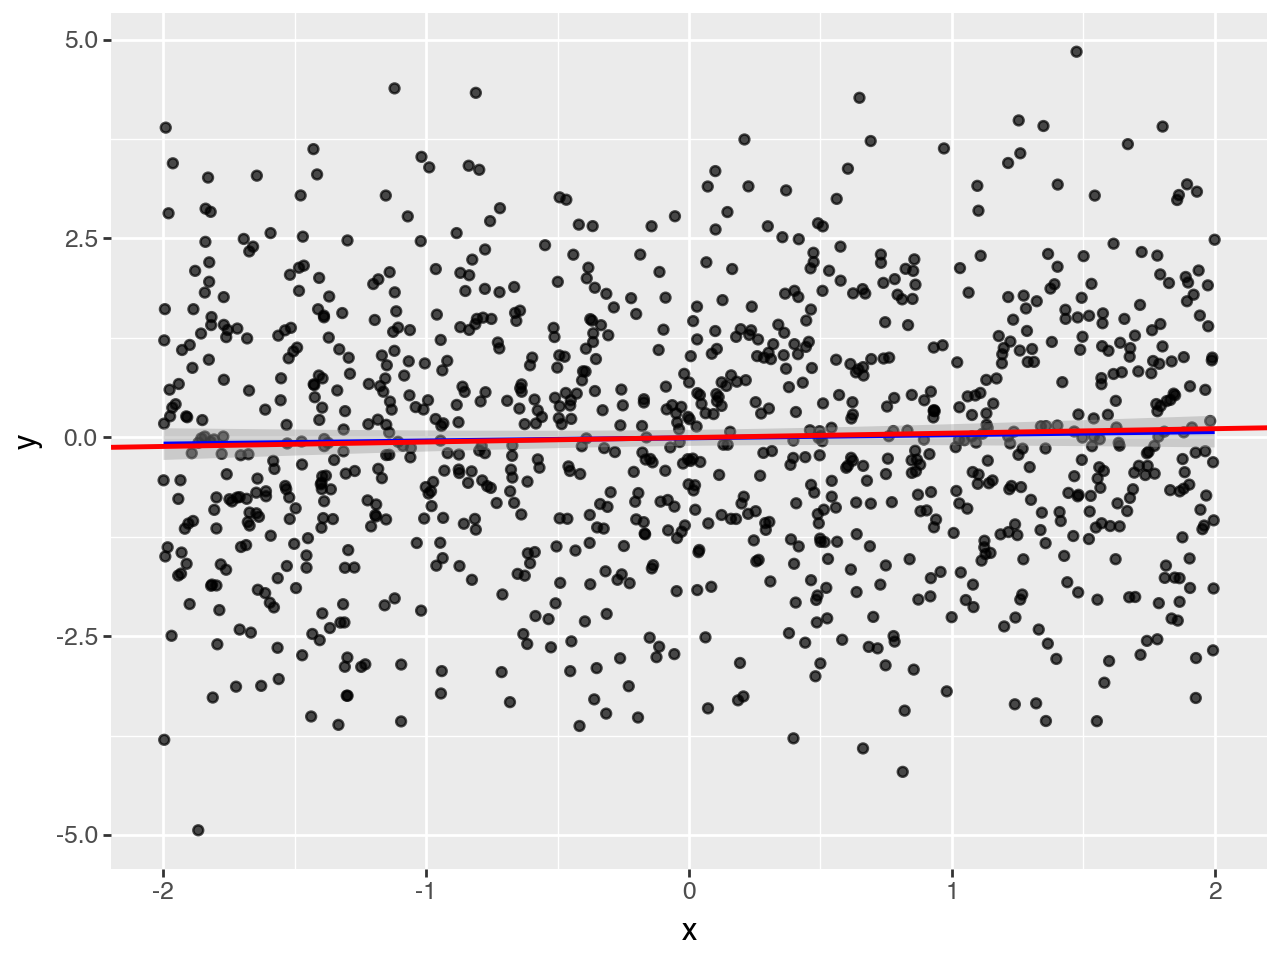

In [15]:
xi = 0
x = X[:,xi]
b0 = model.loc_intercept.value
b = np.asarray(res1.position["lin_coef"][xi])
df = pd.DataFrame(
    {"y": model.response.value, "residual": residual, "z": z, "loc": model.loc.value, "x": x}
)

(
    p9.ggplot(df)
    + p9.aes("x", "y")
    + p9.geom_point(alpha=0.7)
    + p9.geom_smooth(method = "lm", color="blue")
    + p9.geom_abline(intercept=b0, slope=b, color="red", size=1)
)

In [16]:
dist = model.dist_class(model.knots.knots, model.coef.value, loc=0.0, scale=1.0)

In [17]:
mean = dist._transformation_spline_mean()
print(mean)

[-0.00240384]


In [18]:
dist._transformation_spline_variance(mean)

Array([0.9810068], dtype=float32)

In [19]:
residual = jnp.linspace(-4, 4, 301)
pdf = dist.prob(residual)
z, _ = dist.transformation_and_logdet(residual)

df = pd.DataFrame({"residual": residual, "pdf": pdf, "z": z})

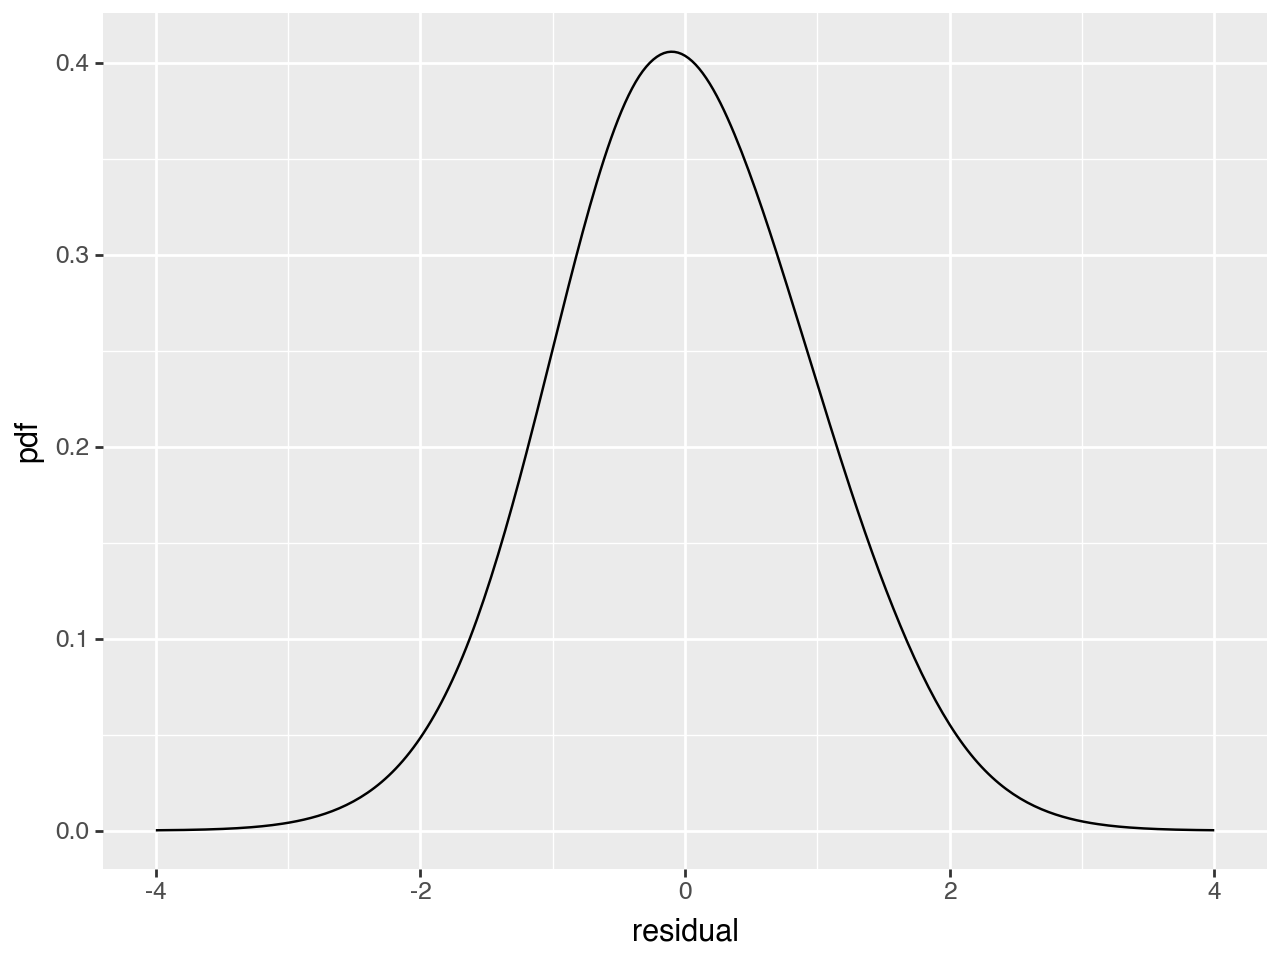

In [20]:
(
    p9.ggplot(df)
    + p9.geom_line(p9.aes("residual", "pdf"))
)

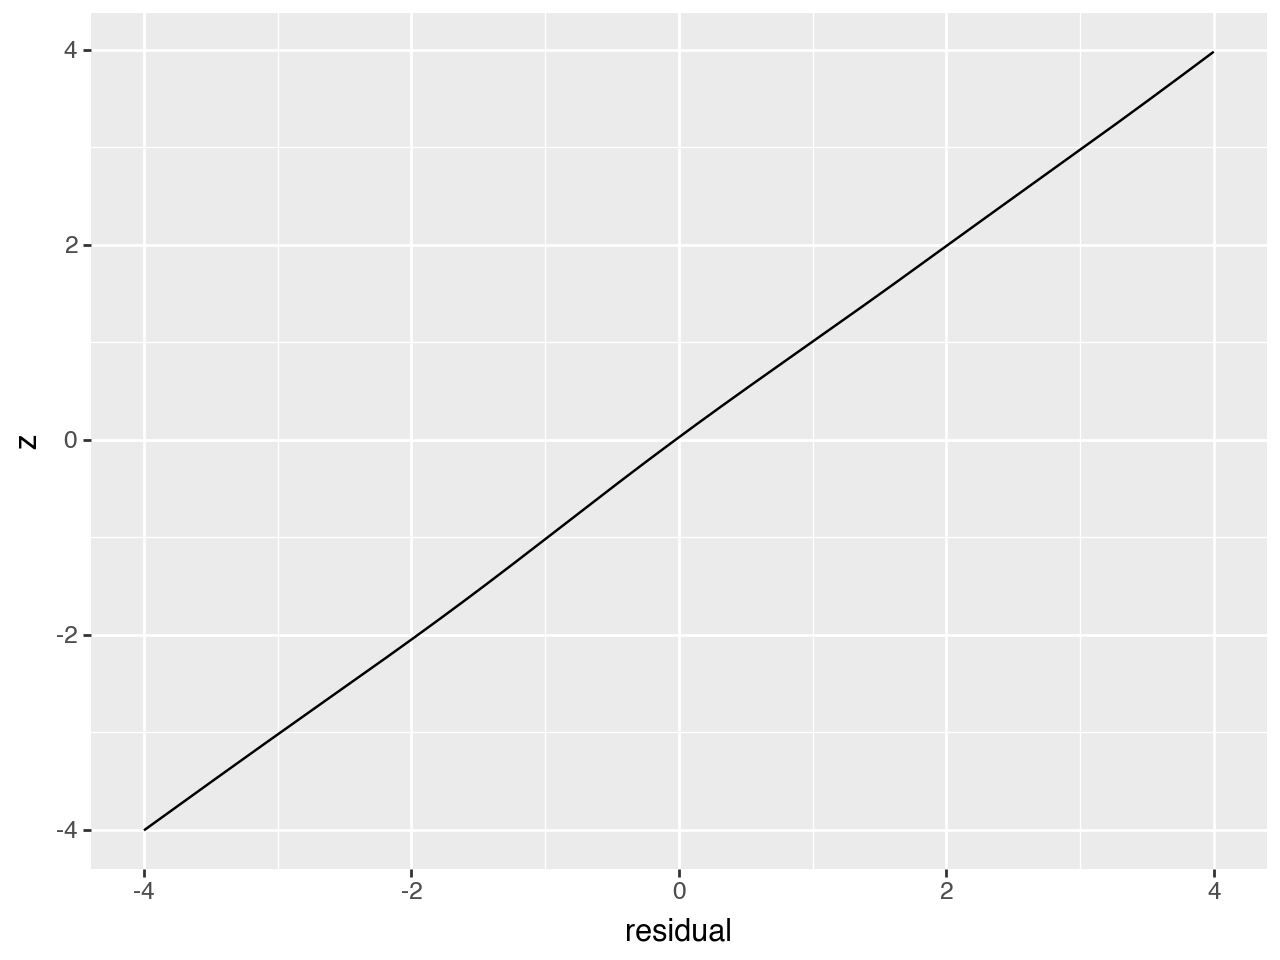

Training loss: 1509.774, Validation loss: 1509.774:  40%|████      | 403/999 [00:22<00:04, 147.88it/s]

In [21]:
(
    p9.ggplot(df)
    + p9.geom_line(p9.aes("residual", "z"))
)